
## Overview
This is a Jupyter notebook to simulate and animate the Dzhanibekov effect of a tumbling T-handle in microgravity. I used SymPy, Python's symbolic mathmatics library, to derive Euler's equations of motion (EoMs) under a torque-free conditon. The EoMs are numerically solved using the odeint package from SciPy. The simulation results will be presented in 3D animation using Matplotlib.
## Defining reference frames and a set of Euler angles
Let N denote a space fixed frame whose basis vectors are given as $\boldsymbol{\hat{n}_x}, \boldsymbol{\hat{n}_y}, \boldsymbol{\hat{n}_z}$, while B denotes a body-fixed frame attached to the T handle whose basis vectors are given as $\boldsymbol{\hat{b}_x}, \boldsymbol{\hat{b}_y}, \boldsymbol{\hat{b}_z}.$ The T-handle's orientation is described using a set of Euler 3-1-3 angles ($\psi, \theta, \phi$) . The geometry of the T-handle and reference frames are given in the figure below where the point G denotes the mass center of the T-handle and $\boldsymbol{\hat{b}_y}$ is aligned with the axis of rotation of the body - the line segment $\overline{AD}$. 

 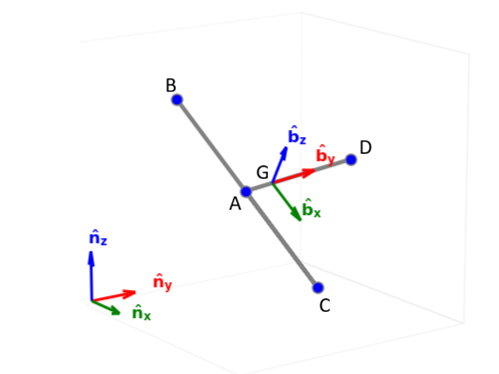

In [1]:
from sympy.physics.mechanics import dynamicsymbols, ReferenceFrame, init_vprinting
init_vprinting()
# Euler angles and thier 1st order time derivatives
psi, theta, phi= dynamicsymbols('psi theta phi') # precession, nutation and spinning
psi_dot = dynamicsymbols('psi',1) 
theta_dot = dynamicsymbols('theta',1) 
phi_dot = dynamicsymbols('phi',1) 
# define reference frames
N = ReferenceFrame('N') # Inertial frame
B = ReferenceFrame('B') # Body frame
# define an Euler angle 3-1-3 set
B.orient_body_fixed(N, (psi, theta, phi), 'ZXZ')

The angular velocity of the body frame B observed from the space-fixed frame N is denoted by $^N\boldsymbol{\omega}^B$ which can be calcuated with SymPy.

In [2]:
# angular velocity of the body frame expressed in terms of the Euler angles
N_w_B = B.ang_vel_in(N)
N_w_B

Rearrange the output [2] in a form a little bit cleaner:
$$^N\boldsymbol{\omega}^B=(\cos{\phi}\, \dot{\theta}+\sin{\phi}\sin{\theta}\,\dot{\psi})\boldsymbol{\hat{b}_x}+(-\sin{\phi}\,\dot{\theta}+\cos{\phi}\sin{\theta}\,\dot{\psi} )\boldsymbol{\hat{b}_y}+ (\cos{\theta}\,\dot{\psi} +\dot{\phi})\boldsymbol{\hat{b}_z}\tag{1}$$
$^N\boldsymbol{\omega}^B$ will also be exressed in angular velocity components of the $\hat{\boldsymbol{b}}_i$ basis vectors:
$$^N\boldsymbol{\omega}^B = \omega_1\boldsymbol{\hat{b}_x} + \omega_2\boldsymbol{\hat{b}_y} + \omega_3\boldsymbol{\hat{b}_z} \tag{2}$$

where $\omega_i\,(i=1,2,3)$ are expressed in terms of Euler angles:
$$
    \begin{align}
        \omega_1 &= \cos{\phi}\,\dot{\theta}+\sin{\phi}\sin{\theta}\,\dot{\psi}\\
        \omega_2 &= -\sin{\phi}\,\dot{\theta}+\cos{\phi}\sin{\theta}\,\dot{\psi} \\
        \omega_3 &= \cos{\theta}\,\dot{\psi} +\dot{\phi}\tag{3}
    \end{align}
$$

In [3]:
# angular velocities about the body's three principal axes and thier 1st order time derivatives
omega_1, omega_2, omega_3 = dynamicsymbols('omega_1 omega_2 omega_3') 
omega_1_dot= dynamicsymbols('omega_1',1) 
omega_2_dot= dynamicsymbols('omega_2',1)
omega_3_dot= dynamicsymbols('omega_3',1)
# angular velocity of the body expressed in the body frame basis vectors
omg=omega_1*B.x+omega_2*B.y+omega_3*B.z
omg

## Deriving Euler Equations of Motion
The angular momentum $\boldsymbol{L}$ of the T-handle about its mass center is given by
$$
\boldsymbol{L} = I_1\omega_1\boldsymbol{\hat{b}_x} +I_2\omega_2\boldsymbol{\hat{b}_y}+I_3\omega_3\boldsymbol{\hat{b}_z} \tag{4}
$$
with its principal moments of inertia $I_1 > I_2 > I_3$. There is no external torque acting on the T-handle, the Euler's equations of motion are:

$$
\frac{^N{d{\boldsymbol{L}}}}{dt} = 0 \tag{5}
$$

where "N" denotes the time-derivative in the space-fixed frame. Using (2) and (4), the left-hand side of (5) becomes:

$$
\begin{align}
\frac{^N{d{\boldsymbol{L}}}}{dt} ={}& I_1\dot{\omega}_1\,\boldsymbol{\hat{b}_x} +I_2\dot{\omega}_2\,\boldsymbol{\hat{b}_y}+I_3\dot{\omega}_3\,\boldsymbol{\hat{b}_z}+^N\boldsymbol{\omega}^B \times \boldsymbol{L} \\ 
=& (I_1\dot{\omega}_1\,-(I_2-I_3)\omega_2\omega_3)\boldsymbol{\hat{b}_x} +  (I_2\dot{\omega}_2\,-(I_3-I_1)\omega_3\omega_1)\boldsymbol{\hat{b}_y}\\ &+  (I_3\dot{\omega}_3\,-(I_1-I_2)\omega_1\omega_2)\boldsymbol{\hat{b}_z}\tag{6}
\end{align}
$$
SymPy can yield the same results with the codes given in [4]．

In [4]:
from sympy import symbols
from sympy.physics.mechanics import inertia
# principal moments of inertia of the body
I_1, I_2, I_3 = symbols('I_1 I_2 I_3') 
# define the intertia tensor of the body
I = inertia(B, I_1, I_2, I_3)
# angular momentum of the body
L = I_1*omega_1*B.x+I_2*omega_2*B.y+I_3*omega_3*B.z
# derive Euler's equations under the torque–free condition
L_dot=L.dt(B)+omg.cross(I.dot(omg)).simplify()
L_dot

## Numerical solution
Now we have a set of first order differential equations given in (3) and (6) with 6 unkonw variables: $\omega_x,\omega_y,\omega_z, \psi, \theta, \phi$. To obtain numerical solutions of the equations with the ODEINT package, rearrange and lamdify them for $\dot{\omega}_x,\dot{\omega}_y,\dot{\omega}_z, \dot{\psi}, \dot{\theta}$ and $\dot{\phi}$. Then define a function for the ODEINT solver.

In [5]:
from sympy import lambdify, solve
# solve the Euler equations
omg_dot = solve(L_dot.to_matrix(B), [omega_1_dot,omega_2_dot,omega_3_dot])
# lamdify the Euler equations for numerical calculation
args_omg_dot = (omega_1, omega_2, omega_3, I_1, I_2, I_3)
omg1_dot_f = lambdify(args_omg_dot, omg_dot[omega_1_dot], "numpy")
omg2_dot_f = lambdify(args_omg_dot, omg_dot[omega_2_dot], "numpy")
omg3_dot_f = lambdify(args_omg_dot, omg_dot[omega_3_dot], "numpy")
# form a set of first-order differential equations to calculate the Euler angles, given omega_1, omega_2 and omega_3
sol_omg = solve((omg-N_w_B).to_matrix(B), [psi_dot, theta_dot, phi_dot])
# lamdify the angular velocity expressed in the Euler angles for numerical calculation
args_omg = [omega_1, omega_2, omega_3, psi, theta, phi]
psi_dot_f = lambdify(args_omg, sol_omg[psi_dot].trigsimp(), "numpy")
theta_dot_f = lambdify(args_omg, sol_omg[theta_dot].trigsimp(), "numpy")
phi_dot_f = lambdify(args_omg, sol_omg[phi_dot].trigsimp(), "numpy")

# Define a function for the odeint solver
def dSdt(S, t):
    omega_1, omega_2, omega_3, psi, theta, phi = S
    return [
        omg1_dot_f(omega_1, omega_2, omega_3, I_1, I_2, I_3),
        omg2_dot_f(omega_1, omega_2, omega_3, I_1, I_2, I_3),
        omg3_dot_f(omega_1, omega_2, omega_3, I_1, I_2, I_3),
        psi_dot_f(omega_1, omega_2, omega_3, psi, theta, phi),
        theta_dot_f(omega_1, omega_2, omega_3, psi, theta, phi),
        phi_dot_f(omega_1, omega_2, omega_3, psi, theta, phi),
    ]

The codes in [6] given below follow a standard procedure to numerically solve ordinary differential equaitons with odeint. The initial condition for the angular velocity about the intermediate axis $\boldsymbol{\hat{b}_y}$ is set as $\omega_2$ = 30 rad/s. Notice that the angular velocities ($\omega_1$ and $\omega_3$) about both first and third principal axes have non-zero small values: 0.1 rad/s each in this case to make the T-handle tumble back and force with "unstable" rotational behaviour.

In [6]:
# principal moments of inertia
# I_2 is associated with the intermideate principal axis
I_1 = 0.2  #  kg-m**2
I_2 = 0.3  #  kg-m**2 
I_3 = 0.4  #  kg-m**2

#  Simulation parameters:
tf = 10              #  s
dt = 0.01            #  s

# initial conditions
omega10 = 0.1        #  rad/s
omega20 = 30.0       #  rad/s
omega30 = 0.1        #  rad/s
psi0 = 0.0           #  rad
theta0 = 0.1         #  rad 
phi0 = 0.0           #  rad
Y0 = [omega10, omega20, omega30, psi0, theta0, phi0]

from scipy.integrate import odeint
import numpy as np
# time span
t = np.arange(0, tf, dt)

# solve the differential equation  
ans = odeint(dSdt, y0=Y0, t=t)
xs = np.transpose(ans)

## Defining T-handle's geometry for 3D animation
The geometry of the object will be created through the use of SymPy in three steps. First define the point objects of the body in the rotating frame B using the ".set_pos()" method, providing each point's relative position to the mass centre. Second convert the points coordinates in the body frame to those in the space-fixed one with the method "to_matrix(N)." Third lamdify the point coordinates in the N frame for 3D animation.

In [7]:
# define the T-handle geometry
from sympy.physics.mechanics import Point
# The line segment AD is in line with the intermideate principal axis about which the body rotates.
Ab = Point('Ab')
Bb = Point('Bb')
Cb = Point('Cb')
Db = Point('Db')
G =  Point('G') # mass center
L_AD=2.0
L_AG=0.5
L_BC=4.0
Ab.set_pos(G, -L_AG*B.y) 
Db.set_pos(Ab, L_AD*B.y) 
Bb.set_pos(Ab, L_BC/2*B.x)
Cb.set_pos(Ab, -L_BC/2*B.x)
# Calucurate T-handle's point coordinates in the inertia frame
coordinates = Db.pos_from(G).to_matrix(N)
for point in [Ab, Bb, Cb]:
    coordinates = coordinates.row_join(point.pos_from(G).to_matrix(N))
# coordinates are lamdified with the Euler angles
eval_point_coords = lambdify([psi,theta,phi], coordinates)

## Animating the T-handle
The codes below follow a standard procedure to animate a 3d object using matplotlib. At each step of the animation function "animate(i)" the cartesian coordinates of the points are calcurated from the ODEINT result for the Euler angles.

In [ ]:
# animate the T-handle motion
%matplotlib widget
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection ='3d')
ax.set_box_aspect((1,1,1))

line_prop = {
    'color': 'black',
    'marker': 'o',
    'markerfacecolor': 'blue',
    'markersize': 10,
}
lm=3
def animate(i):
    plt.cla()
    x, y, z = eval_point_coords(xs[3,i],xs[4,i],xs[5,i])
    lines_3d, = ax.plot(x, y, z, **line_prop)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_xlim((-lm, lm))
    ax.set_ylim((-lm, lm))
    ax.set_zlim((-lm, lm))

ani = FuncAnimation(fig, animate, len(t),interval=30)

## References
https://rotations.berkeley.edu/a-tumbling-t-handle-in-space/